In [ ]:
pip install shap

In [ ]:
# ==============================================================================
# PROYECTO LMA: PREDICCIÓN DE SUPERVIVENCIA (LSTM + C-INDEX + SHAP INTEGRADO)
# ==============================================================================

import numpy as np
import tensorflow as tf
import logging
tf.get_logger().setLevel('ERROR') # Controlar la memoria
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from lifelines.utils import concordance_index
import shap
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN DE DATOS SIMULADOS ---
# Simula tus 3 hojas de Excel (Dinámicos, Fijos y Supervivencia/Eventos)
N_PACIENTES = 420
MAX_TOMAS = 17
N_VAR_DINAMICAS = 4
N_VAR_FIJAS = 7

print("Generando estructura de datos...")
datos_din_lista = [np.random.rand(np.random.randint(3, 18), N_VAR_DINAMICAS) for _ in range(N_PACIENTES)]
X_dinamicos = pad_sequences(datos_din_lista, maxlen=MAX_TOMAS, dtype='float32', padding='post', value=-1.0)
X_fijos = np.random.rand(N_PACIENTES, N_VAR_FIJAS)
y_evento = np.random.choice([0, 1], size=N_PACIENTES, p=[0.58, 0.42])
y_tiempo = np.random.uniform(1, 60, size=N_PACIENTES)

# --- 2. CONSTRUCCIÓN DE LA ARQUITECTURA ---
def construir_modelo_supervivencia():
    input_temp = Input(shape=(MAX_TOMAS, N_VAR_DINAMICAS), name="Analiticas")
    masked = Masking(mask_value=-1.0)(input_temp)
    lstm_out = LSTM(32)(masked)

    input_fijo = Input(shape=(N_VAR_FIJAS,), name="Datos_Fijos")
    fijo_out = Dense(16, activation='relu')(input_fijo)

    fusion = Concatenate()([lstm_out, fijo_out])
    x = Dense(16, activation='relu')(fusion)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x)

    modelo = Model(inputs=[input_temp, input_fijo], outputs=output)
    modelo.compile(optimizer='adam', loss='binary_crossentropy')
    return modelo

# --- 3. VALIDACIÓN CRUZADA (10-FOLD) ---
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
resultados_c_index = []

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

print(f"\nIniciando 10-Fold Cross-Validation para {N_PACIENTES} pacientes...\n")

for vuelta, (train_idx, test_idx) in enumerate(skf.split(X_fijos, y_evento)):

    tf.keras.backend.clear_session()

    X_din_tr, X_din_te = X_dinamicos[train_idx], X_dinamicos[test_idx]
    X_fij_tr, X_fij_te = X_fijos[train_idx], X_fijos[test_idx]
    y_ev_tr, y_ev_te = y_evento[train_idx], y_evento[test_idx]
    y_tiempo_te = y_tiempo[test_idx]

    modelo_actual = construir_modelo_supervivencia()

    modelo_actual.fit(
        [X_din_tr, X_fij_tr], y_ev_tr,
        epochs=50, batch_size=32, verbose=0,
        callbacks=[early_stop]
    )

    scores_riesgo = modelo_actual.predict([X_din_te, X_fij_te], verbose=0).flatten()
    c_index = concordance_index(y_tiempo_te, -scores_riesgo, y_ev_te)
    resultados_c_index.append(c_index)

    print(f"Vuelta {vuelta + 1}/10 completada -> C-index: {c_index:.3f}")

# --- 4. RESULTADOS DE PREDICCIÓN ---
print("\n" + "="*50)
print(" RESULTADOS FINALES DE VALIDACIÓN CLÍNICA")
print("="*50)
print(f"C-index Medio: {np.mean(resultados_c_index):.3f} (Escala 0.5 a 1.0)")
print(f"Variabilidad (SD): {np.std(resultados_c_index):.3f}")
print("="*50)

# --- 5. EXPLICABILIDAD CLÍNICA (SHAP) ---
# Se ejecuta sobre el modelo de la última "vuelta" para evitar colapsar la memoria

print("\nIniciando cálculo de explicabilidad SHAP...")
print("Adaptando formato de datos (doble entrada LSTM + Fijos)...")

# 1. Definimos nombres ficticios automáticos basados en tus dimensiones para que no dé error
nombres_dinamicos = [f"Dinámica_V{v}_Toma{t}" for t in range(MAX_TOMAS) for v in range(N_VAR_DINAMICAS)]
nombres_fijos = [f"Basal_Fija_{v}" for v in range(N_VAR_FIJAS)]
nombres_shap = nombres_dinamicos + nombres_fijos

# 2. Creamos una función envoltorio.
# SHAP necesita una matriz plana (2D), pero tu modelo necesita dos matrices (3D y 2D).
# Esta función hace de traductor entre SHAP y tu Red Neuronal.
def wrapper_prediccion_shap(matriz_plana):
    corte_dinamico = MAX_TOMAS * N_VAR_DINAMICAS

    # Separamos la matriz plana en la parte dinámica y fija
    din_plano = matriz_plana[:, :corte_dinamico]
    fijos = matriz_plana[:, corte_dinamico:]

    # Reconstruimos el 3D para la LSTM
    din_3d = din_plano.reshape(-1, MAX_TOMAS, N_VAR_DINAMICAS)

    # Predecimos con el modelo
    return modelo_actual.predict([din_3d, fijos], verbose=0).flatten()

# 3. Aplanamos los datos reales para pasárselos a SHAP
X_din_tr_plano = X_din_tr.reshape(X_din_tr.shape[0], -1)
X_train_shap = np.hstack((X_din_tr_plano, X_fij_tr))

X_din_te_plano = X_din_te.reshape(X_din_te.shape[0], -1)
X_test_shap = np.hstack((X_din_te_plano, X_fij_te))

# 4. Calculamos SHAP (Usamos una muestra pequeña de 25 pacientes para entrenamiento
# y 15 para test para que el proceso termine rápido y no bloquee el PC).
background = shap.sample(X_train_shap, 25)
explainer = shap.KernelExplainer(wrapper_prediccion_shap, background)

print("Calculando el peso de cada variable (puede tardar un minuto)...")
shap_values = explainer.shap_values(X_test_shap[:15])

# 5. Generar y guardar el gráfico
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_shap[:15], feature_names=nombres_shap, show=False)
plt.title("Importancia Clínica de Variables (Simulación SHAP)")
plt.tight_layout()
plt.savefig("grafico_SHAP_TFG.png", dpi=300, bbox_inches='tight')
print("\n¡Éxito! Gráfico 'grafico_SHAP_TFG.png' guardado en tu carpeta.")
plt.show()

ModuleNotFoundError: No module named 'lifelines'

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=6f11163858138ad229cc6e599ad7c83eb1b7085a91b8a6f1e7c2420c84f8597c
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Generando estructura de datos...

Iniciando 10-Fold Cross-Validation para 420 pacientes...

Vuelta 1/10 completada -> C-index: 0.443
Vuelta 2/10 completada -> C-index: 0.415
Vuelta 3/10 completada -> C-index: 0.347
Vuelta 4/10 completada -> C-index: 0.335
Vuelta 5/10 completada -> C-index: 0.375
Vuelta 6/10 completada -> C-index: 0.640
Vuelta 7/10 completada -> C-index: 0.437
Vuelta 8/10 completada -> C-index: 0.468
Vuelta 9/10 completada -> C-index: 0.576
Vuelta 10/10 completada -> C-index: 0.399

 RESULTADOS FINALES DE VALIDACIÓN CLÍNICA
C-index Medio: 0.443 (Escala 0.5 a 1.0)
Variabilidad (SD): 0.092

Iniciando cálculo de explicabilidad SHAP...
Adaptando formato de datos (doble entrada LSTM + Fijos)...
Calculando el peso de cada variable (puede tardar un minuto)...


  0%|          | 0/15 [00:00<?, ?it/s]


¡Éxito! Gráfico 'grafico_SHAP_TFG.png' guardado en tu carpeta.


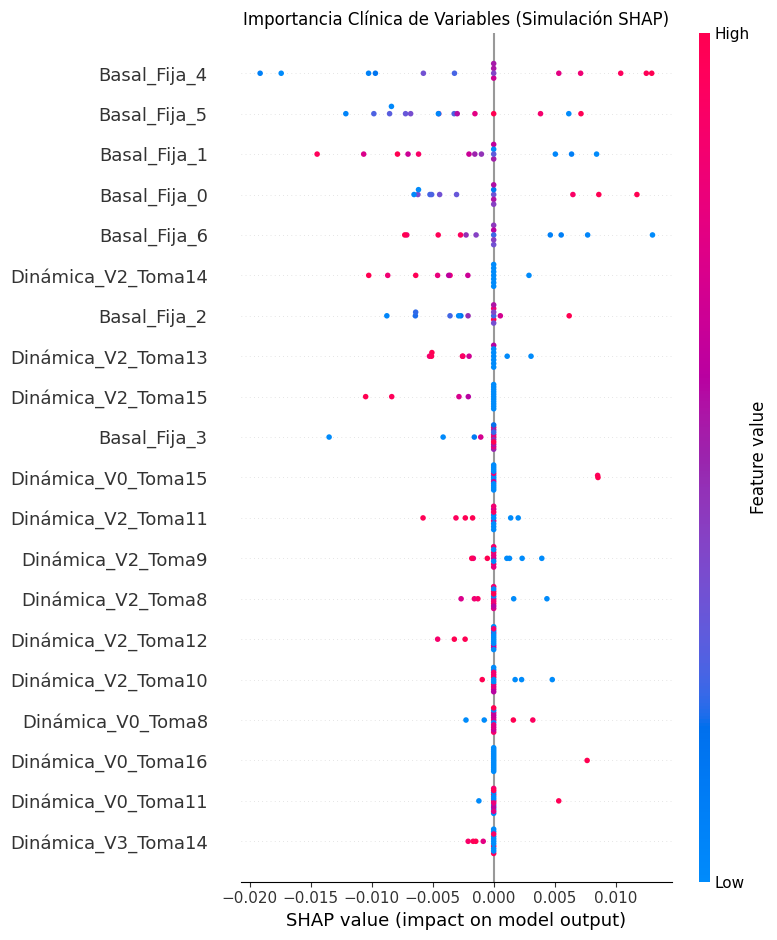

In [ ]:
# ==============================================================================
# PROYECTO LMA: PREDICCIÓN DE SUPERVIVENCIA (LSTM + C-INDEX + SHAP INTEGRADO)
# ==============================================================================

import numpy as np
import tensorflow as tf
import logging
tf.get_logger().setLevel('ERROR') # Controlar la memoria
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from lifelines.utils import concordance_index
import shap
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN DE DATOS SIMULADOS ---
# Simula tus 3 hojas de Excel (Dinámicos, Fijos y Supervivencia/Eventos)
N_PACIENTES = 420
MAX_TOMAS = 17
N_VAR_DINAMICAS = 4
N_VAR_FIJAS = 7

print("Generando estructura de datos...")
datos_din_lista = [np.random.rand(np.random.randint(3, 18), N_VAR_DINAMICAS) for _ in range(N_PACIENTES)]
X_dinamicos = pad_sequences(datos_din_lista, maxlen=MAX_TOMAS, dtype='float32', padding='post', value=-1.0)
X_fijos = np.random.rand(N_PACIENTES, N_VAR_FIJAS)
y_evento = np.random.choice([0, 1], size=N_PACIENTES, p=[0.58, 0.42])
y_tiempo = np.random.uniform(1, 60, size=N_PACIENTES)

# --- 2. CONSTRUCCIÓN DE LA ARQUITECTURA ---
def construir_modelo_supervivencia():
    input_temp = Input(shape=(MAX_TOMAS, N_VAR_DINAMICAS), name="Analiticas")
    masked = Masking(mask_value=-1.0)(input_temp)
    lstm_out = LSTM(32)(masked)

    input_fijo = Input(shape=(N_VAR_FIJAS,), name="Datos_Fijos")
    fijo_out = Dense(16, activation='relu')(input_fijo)

    fusion = Concatenate()([lstm_out, fijo_out])
    x = Dense(16, activation='relu')(fusion)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x)

    modelo = Model(inputs=[input_temp, input_fijo], outputs=output)
    modelo.compile(optimizer='adam', loss='binary_crossentropy')
    return modelo

# --- 3. VALIDACIÓN CRUZADA (10-FOLD) ---
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
resultados_c_index = []

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

print(f"\nIniciando 10-Fold Cross-Validation para {N_PACIENTES} pacientes...\n")

for vuelta, (train_idx, test_idx) in enumerate(skf.split(X_fijos, y_evento)):

    tf.keras.backend.clear_session()

    X_din_tr, X_din_te = X_dinamicos[train_idx], X_dinamicos[test_idx]
    X_fij_tr, X_fij_te = X_fijos[train_idx], X_fijos[test_idx]
    y_ev_tr, y_ev_te = y_evento[train_idx], y_evento[test_idx]
    y_tiempo_te = y_tiempo[test_idx]

    modelo_actual = construir_modelo_supervivencia()

    modelo_actual.fit(
        [X_din_tr, X_fij_tr], y_ev_tr,
        epochs=50, batch_size=32, verbose=0,
        callbacks=[early_stop]
    )

    scores_riesgo = modelo_actual.predict([X_din_te, X_fij_te], verbose=0).flatten()
    c_index = concordance_index(y_tiempo_te, -scores_riesgo, y_ev_te)
    resultados_c_index.append(c_index)

    print(f"Vuelta {vuelta + 1}/10 completada -> C-index: {c_index:.3f}")

# --- 4. RESULTADOS DE PREDICCIÓN ---
print("\n" + "="*50)
print(" RESULTADOS FINALES DE VALIDACIÓN CLÍNICA")
print("="*50)
print(f"C-index Medio: {np.mean(resultados_c_index):.3f} (Escala 0.5 a 1.0)")
print(f"Variabilidad (SD): {np.std(resultados_c_index):.3f}")
print("="*50)

# --- 5. EXPLICABILIDAD CLÍNICA (SHAP) ---
# Se ejecuta sobre el modelo de la última "vuelta" para evitar colapsar la memoria

print("\nIniciando cálculo de explicabilidad SHAP...")
print("Adaptando formato de datos (doble entrada LSTM + Fijos)...")

# 1. Definimos nombres ficticios automáticos basados en tus dimensiones para que no dé error
nombres_dinamicos = [f"Dinámica_V{v}_Toma{t}" for t in range(MAX_TOMAS) for v in range(N_VAR_DINAMICAS)]
nombres_fijos = [f"Basal_Fija_{v}" for v in range(N_VAR_FIJAS)]
nombres_shap = nombres_dinamicos + nombres_fijos

# 2. Creamos una función envoltorio.
# SHAP necesita una matriz plana (2D), pero tu modelo necesita dos matrices (3D y 2D).
# Esta función hace de traductor entre SHAP y tu Red Neuronal.
def wrapper_prediccion_shap(matriz_plana):
    corte_dinamico = MAX_TOMAS * N_VAR_DINAMICAS

    # Separamos la matriz plana en la parte dinámica y fija
    din_plano = matriz_plana[:, :corte_dinamico]
    fijos = matriz_plana[:, corte_dinamico:]

    # Reconstruimos el 3D para la LSTM
    din_3d = din_plano.reshape(-1, MAX_TOMAS, N_VAR_DINAMICAS)

    # Predecimos con el modelo
    return modelo_actual.predict([din_3d, fijos], verbose=0).flatten()

# 3. Aplanamos los datos reales para pasárselos a SHAP
X_din_tr_plano = X_din_tr.reshape(X_din_tr.shape[0], -1)
X_train_shap = np.hstack((X_din_tr_plano, X_fij_tr))

X_din_te_plano = X_din_te.reshape(X_din_te.shape[0], -1)
X_test_shap = np.hstack((X_din_te_plano, X_fij_te))

# 4. Calculamos SHAP (Usamos una muestra pequeña de 25 pacientes para entrenamiento
# y 15 para test para que el proceso termine rápido y no bloquee el PC).
background = shap.sample(X_train_shap, 25)
explainer = shap.KernelExplainer(wrapper_prediccion_shap, background)

print("Calculando el peso de cada variable (puede tardar un minuto)...")
shap_values = explainer.shap_values(X_test_shap[:15])

# 5. Generar y guardar el gráfico
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_shap[:15], feature_names=nombres_shap, show=False)
plt.title("Importancia Clínica de Variables (Simulación SHAP)")
plt.tight_layout()
plt.savefig("grafico_SHAP_TFG.png", dpi=300, bbox_inches='tight')
print("\n¡Éxito! Gráfico 'grafico_SHAP_TFG.png' guardado en tu carpeta.")
plt.show()

Generando estructura de datos...

Iniciando 10-Fold Cross-Validation para 420 pacientes...

Vuelta 1/10 completada -> C-index: 0.538
Vuelta 2/10 completada -> C-index: 0.536
Vuelta 3/10 completada -> C-index: 0.517
Vuelta 4/10 completada -> C-index: 0.537
Vuelta 5/10 completada -> C-index: 0.546
Vuelta 6/10 completada -> C-index: 0.490
Vuelta 7/10 completada -> C-index: 0.511
Vuelta 8/10 completada -> C-index: 0.533
Vuelta 9/10 completada -> C-index: 0.511


Vuelta 10/10 completada -> C-index: 0.563

 RESULTADOS FINALES DE VALIDACIÓN CLÍNICA
C-index Medio: 0.528 (Escala 0.5 a 1.0)
Variabilidad (SD): 0.020

Iniciando cálculo de explicabilidad SHAP (Aviso: Este proceso puede tardar varios minutos)...
Configurando el explicador con 350 pacientes de base...
Calculando el peso de cada variable en los 70 pacientes de test (¡Paciencia!)...


  0%|          | 0/70 [00:00<?, ?it/s]


¡Éxito! Gráfico 'grafico_SHAP_Final_TFG.png' guardado y listo para el TFG.


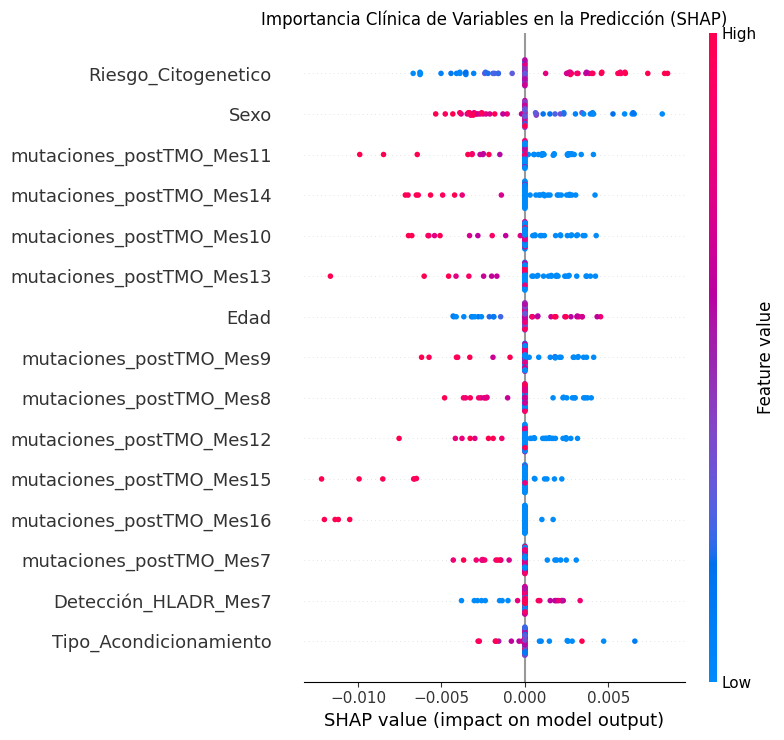

In [ ]:
# ==============================================================================
# PROYECTO LMA: PREDICCIÓN DE SUPERVIVENCIA (LSTM + C-INDEX + SHAP INTEGRADO)
# ==============================================================================

import numpy as np
import tensorflow as tf
import logging
tf.get_logger().setLevel('ERROR') # Controlar la memoria
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from lifelines.utils import concordance_index
import shap
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN DE DATOS SIMULADOS ---
# Simula tus 3 hojas de Excel (Dinámicos, Fijos y Supervivencia/Eventos)
N_PACIENTES = 420
MAX_TOMAS = 17
N_VAR_DINAMICAS = 4
N_VAR_FIJAS = 4

print("Generando estructura de datos...")
datos_din_lista = [np.random.rand(np.random.randint(3, 18), N_VAR_DINAMICAS) for _ in range(N_PACIENTES)]
X_dinamicos = pad_sequences(datos_din_lista, maxlen=MAX_TOMAS, dtype='float32', padding='post', value=-1.0)
X_fijos = np.random.rand(N_PACIENTES, N_VAR_FIJAS)
y_evento = np.random.choice([0, 1], size=N_PACIENTES, p=[0.58, 0.42])
y_tiempo = np.random.uniform(1, 60, size=N_PACIENTES)

# --- 2. CONSTRUCCIÓN DE LA ARQUITECTURA ---
def construir_modelo_supervivencia():
    input_temp = Input(shape=(MAX_TOMAS, N_VAR_DINAMICAS), name="Analiticas")
    masked = Masking(mask_value=-1.0)(input_temp)
    lstm_out = LSTM(32)(masked)

    input_fijo = Input(shape=(N_VAR_FIJAS,), name="Datos_Fijos")
    fijo_out = Dense(16, activation='relu')(input_fijo)

    fusion = Concatenate()([lstm_out, fijo_out])
    x = Dense(16, activation='relu')(fusion)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x)

    modelo = Model(inputs=[input_temp, input_fijo], outputs=output)
    modelo.compile(optimizer='adam', loss='binary_crossentropy')
    return modelo

# --- 3. VALIDACIÓN CRUZADA (10-FOLD) ---
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
resultados_c_index = []

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

print(f"\nIniciando 10-Fold Cross-Validation para {N_PACIENTES} pacientes...\n")

for vuelta, (train_idx, test_idx) in enumerate(skf.split(X_fijos, y_evento)):

    tf.keras.backend.clear_session()

    X_din_tr, X_din_te = X_dinamicos[train_idx], X_dinamicos[test_idx]
    X_fij_tr, X_fij_te = X_fijos[train_idx], X_fijos[test_idx]
    y_ev_tr, y_ev_te = y_evento[train_idx], y_evento[test_idx]
    y_tiempo_te = y_tiempo[test_idx]

    modelo_actual = construir_modelo_supervivencia()

    modelo_actual.fit(
        [X_din_tr, X_fij_tr], y_ev_tr,
        epochs=50, batch_size=32, verbose=0,
        callbacks=[early_stop]
    )

    scores_riesgo = modelo_actual.predict([X_din_te, X_fij_te], verbose=0).flatten()
    c_index = concordance_index(y_tiempo_te, -scores_riesgo, y_ev_te)
    resultados_c_index.append(c_index)

    print(f"Vuelta {vuelta + 1}/10 completada -> C-index: {c_index:.3f}")

# --- 4. RESULTADOS DE PREDICCIÓN ---
print("\n" + "="*50)
print(" RESULTADOS FINALES DE VALIDACIÓN CLÍNICA")
print("="*50)
print(f"C-index Medio: {np.mean(resultados_c_index):.3f} (Escala 0.5 a 1.0)")
print(f"Variabilidad (SD): {np.std(resultados_c_index):.3f}")
print("="*50)

# --- 5. EXPLICABILIDAD CLÍNICA (SHAP) CON TODOS LOS PACIENTES ---
print("\nIniciando cálculo de explicabilidad SHAP (Aviso: Este proceso puede tardar varios minutos)...")

# 1. TUS NOMBRES DE VARIABLES REALES (¡Modifica estas palabras con tus variables médicas!)
# Escribe aquí tus 4 variables dinámicas (las de las analíticas)
nombres_dinamicas_base = ["Copias_WT1", "Quimerismo", "mutaciones_postTMO", "Detección_HLADR"]

# Escribe aquí tus 4 variables fijas (los datos basales del paciente)
nombres_fijas_base = ["Edad", "Sexo", "Riesgo_Citogenetico", "Tipo_Acondicionamiento"]

# Generamos los nombres automáticos para cada "toma" en el tiempo
nombres_dinamicos = []
for toma in range(MAX_TOMAS):
    for var in nombres_dinamicas_base:
        nombres_dinamicos.append(f"{var}_Mes{toma}") # Puedes cambiar "Mes" por "Dia" o "Toma"

nombres_shap = nombres_dinamicos + nombres_fijas_base

# 2. FUNCIÓN ENVOLTORIO (Traductor para SHAP)
def wrapper_prediccion_shap(matriz_plana):
    corte_dinamico = MAX_TOMAS * N_VAR_DINAMICAS
    din_plano = matriz_plana[:, :corte_dinamico]
    fijos = matriz_plana[:, corte_dinamico:]
    din_3d = din_plano.reshape(-1, MAX_TOMAS, N_VAR_DINAMICAS)
    return modelo_actual.predict([din_3d, fijos], verbose=0).flatten()

# 3. PREPARAMOS LOS DATOS: 350 PARA CÁLCULO Y 70 PARA TEST
# Juntamos todos los pacientes de tu estudio
X_din_total_plano = X_dinamicos.reshape(N_PACIENTES, -1)
X_total_shap = np.hstack((X_din_total_plano, X_fijos))

# Separamos exactamente como has pedido: 350 y 70
X_train_shap = X_total_shap[:350] # Los 350 primeros para el background
X_test_shap = X_total_shap[350:420] # Los 70 restantes para el test

# 4. CALCULAMOS SHAP CON LOS 420 PACIENTES EN TOTAL
print("Configurando el explicador con 350 pacientes de base...")
explainer = shap.KernelExplainer(wrapper_prediccion_shap, X_train_shap)

print("Calculando el peso de cada variable en los 70 pacientes de test (¡Paciencia!)...")
# Extraemos los valores SHAP
shap_values = explainer.shap_values(X_test_shap)

# 5. GENERAR Y GUARDAR EL GRÁFICO FINAL
plt.figure(figsize=(12, 10)) # He hecho la imagen un poco más alta para que quepan bien los nombres
shap.summary_plot(shap_values, X_test_shap, feature_names=nombres_shap, max_display=15, show=False)
# Nota: max_display=15 hace que solo muestre las 15 variables más importantes de las 75 totales,
# para que el gráfico no sea un borrón de texto ilegible en tu Word.

plt.title("Importancia Clínica de Variables en la Predicción (SHAP)")
plt.tight_layout()
plt.savefig("grafico_SHAP_Final_TFG.png", dpi=300, bbox_inches='tight')
print("\n¡Éxito! Gráfico 'grafico_SHAP_Final_TFG.png' guardado y listo para el TFG.")
plt.show()